# Build Sentinel-1 Data Cubes

`xcube-eopf` is a Python package that extends [xcube](https://xcube.readthedocs.io/en/latest) with a new [data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#available-data-stores) called `"eopf-zarr"`. This plugin enables the creation of analysis-ready data cubes (ARDC) from multiple Sentinel products published by the [EOPF Sentinel Zarr Sample Service](https://zarr.eopf.copernicus.eu/).

In this notebook, we demonstrate how to use the **xcube EOPF data store** to access multiple **Sentinel-1** EOPF Zarr products and generate 3D analysis-ready data cubes (ARDC).

For a general introduction to the xcube EOPF Data Store, see the [introduction notebook](https://eopf-sample-service.github.io/xcube-eopf/examples/introduction/).  

- 🐙 **GitHub:** [EOPF Sample Service – xcube-eopf](https://github.com/EOPF-Sample-Service/xcube-eopf)  
- ❗ **Issue Tracker:** [Submit or view issues](https://github.com/EOPF-Sample-Service/xcube-eopf/issues)  
- 📘 **Documentation:** [xarray-eopf Docs](https://eopf-sample-service.github.io/xcube-eopf/)

---

## Main Features of the xcube-eopf Data Store for Sentinel-1

Sentinel-1 provides **C-band Synthetic Aperture Radar (SAR)** data. Unlike optical sensors, SAR actively transmits microwave pulses and measures the returned signal, enabling observations independent of daylight and largely unaffected by cloud cover.

Each pixel measures the **radar backscatter**, i.e., the fraction of the emitted microwave energy reflected back to the satellite. Bright pixels indicate strong reflections, while dark pixels indicate weak reflections. The measured backscatter depends on factors such as surface roughness, moisture content, geometry, and vegetation structure.

Sentinel-1 supports several radar polarization combinations:

- **VV** – Vertical transmit, Vertical receive
- **VH** – Vertical transmit, Horizontal receive
- **HH** – Horizontal transmit, Horizontal receive
- **HV** – Horizontal transmit, Vertical receive

The available polarization combinations depend on the acquisition mode.

The main Sentinel-1 product types are:

| Product | Description | Typical applications | STAC Collection |
|---------|-------------|----------------------|-----------------|
| **SLC (Single Look Complex)** | Complex-valued radar data (amplitude and phase) in slant-range geometry. | Interferometry (InSAR), ground deformation, DEM generation | [sentinel-1-l1-slc](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-slc) |
| **GRD (Ground Range Detected)** | Detected radar intensity projected to ground-range geometry. Easier to use than SLC for most applications. | Flood mapping, sea ice, agriculture, ship detection | [sentinel-1-l1-grd](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l1-grd) |
| **OCN (Ocean)** | Ocean geophysical products including wind, wave, and surface current information. | Oceanography, marine weather, offshore monitoring | [sentinel-1-l2-ocn](https://stac.browser.user.eopf.eodc.eu/collections/sentinel-1-l2-ocn) |


### Data Cube Generation Workflow

1. **STAC query:** Retrieve all matching STAC Items based on the requested spatial (`bbox`) and temporal (`time_range`) extent.
2. **Grouping:** Group the retrieved items by acquisition day, relative orbit, orbit direction (ascending or descending), and satellite platform.
3. **Opening:** Open each product in analysis mode using **xarray-eopf**.
   - **GRD:** Performs radiometric calibration, geocoding based on zero-Doppler geometry using a DEM, and radiometric terrain correction. If no DEM is provided, the **Copernicus DEM GLO-30** is automatically retrieved from CDSE. See the [GRD documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-1-level-1-grd).
   - **SLC:** Performs radiometric calibration, TOPSAR burst debursting and merging, geocoding based on zero-Doppler geometry using a DEM, and radiometric terrain correction. If no DEM is provided, the **Copernicus DEM GLO-30** is automatically retrieved from CDSE. See the [SLC documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-1-level-1-slc).
   - **OCN:** Rectifies the irregular measurement grid to a regular spatial grid. See the [OCN documentation](https://eopf-sample-service.github.io/xarray-eopf/guide/#sentinel-1-level-2-ocn).
4. **Mosaicking:** Merge adjacent tiles acquired on the same day into seamless scenes.
5. **Stacking:** Stack the daily mosaics along the temporal dimension to create multi-temporal data cubes for each variable.


📚 **Further reading:** [xcube-eopf Sentinel-1 Documentation](https://eopf-sample-service.github.io/xcube-eopf/guide/#sentinel-1)

---

## Import Modules

The `xcube-eopf` data store is provided as a plugin for `xcube`. Once installed, it registers automatically, allowing you to import `xcube` just like any other [xcube data store](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-access):

In [1]:
import os

import matplotlib.pyplot as plt
from xcube.core.store import new_data_store
from xcube_resampling.utils import reproject_bbox

## Access Sentinel-1 Level-1 GRD ARDC

In this section, we demonstrate the available features and options for opening and generating spatio-temporal data cubes from multiple **Sentinel-1 Level-1 GRD** tiles. To initialize an `eopf-zarr` data store, run the cell below:

> Note: Support for Sentinel-1 GRD products is currently experimental and under validation. Some conversion parameters are missing in the new EOPF product, which are currently estimated. Newer EOPF product version will include these parameters.

In [2]:
store = new_data_store("eopf-zarr")

The data IDs point to [STAC collections](https://stac.browser.user.eopf.eodc.eu). In the following cell we can list the available data IDs.

In [3]:
store.list_data_ids()

['sentinel-1-l1-grd',
 'sentinel-1-l1-slc',
 'sentinel-1-l2-ocn',
 'sentinel-2-l1c',
 'sentinel-2-l2a',
 'sentinel-3-olci-l1-efr',
 'sentinel-3-olci-l2-lfr',
 'sentinel-3-slstr-l1-rbt',
 'sentinel-3-slstr-l2-lst']

Below, you can explore the parameters of the `open_data()` method for each supported data product. The following cell generates a JSON schema listing all available opening parameters for Sentinel-2 Level-2A products.

In [4]:
store.get_open_data_params_schema(data_id="sentinel-1-l1-grd")

### Setup CDSE S3 Credentials for COP DEM 30 Retrieval

Before proceeding, CDSE S3 credentials must be configured to enable access to the CopDEM (30 m) dataset from CDSE. Instructions for generating credentials are available [here](https://documentation.dataspace.copernicus.eu/APIs/S3.html#generate-secrets).

In [5]:
os.environ.update(
    {
        "AWS_ACCESS_KEY_ID": "xxx",
        "AWS_SECRET_ACCESS_KEY": "xxx",
    }
)

### Spatio-Temporal Selection

We now generate a data cube from the Sentinel-1 Level-1 GRD product by setting `data_id` to `"sentinel-1-l1-grd"`.
The bounding box is defined to cover **Zakynthos**, while the temporal range is restricted to a few days in May 2026.

We begin by creating the data cube in `"EPSG:4326"`, which is the coordinate reference system (CRS) of the **Copernicus DEM GLO-30** dataset used for geocoding and solving the inverse zero-Doppler equation.

In [6]:
bbox = [20.6, 37.6, 21., 38.]
time_range = ["2026-05-04", "2026-05-05"]

In [7]:
%%time
ds = store.open_data(
    data_id="sentinel-1-l1-grd",
    bbox=bbox,
    time_range=time_range,
)
ds

CPU times: user 25.9 s, sys: 4.97 s, total: 30.9 s
Wall time: 50 s


<xarray.Dataset> Size: 50MB
Dimensions:      (time: 3, lat: 1441, lon: 1441)
Coordinates:
  * time         (time) datetime64[s] 24B 2026-05-04T16:40:16 ... 2026-05-05T...
  * lat          (lat) float64 12kB 38.0 38.0 38.0 38.0 ... 37.6 37.6 37.6 37.6
  * lon          (lon) float64 12kB 20.6 20.6 20.6 20.6 ... 21.0 21.0 21.0 21.0
    spatial_ref  int64 8B 0
Data variables:
    gamma0_vv    (time, lat, lon) float32 25MB dask.array<chunksize=(1, 1441, 1441), meta=np.ndarray>
    gamma0_vh    (time, lat, lon) float32 25MB dask.array<chunksize=(1, 1441, 1441), meta=np.ndarray>
Attributes: (5)

> **Note:** The 3D data cube generation is fully **lazy**. Data access and processing operations (e.g., downloading, mosaicking, and stacking) are only executed **on demand** and are triggered when the data is explicitly computed, written, or visualized.

As an example, the following cell visualizes a single timestamp of the **gamma nought VV** backscatter band (`gamma0_vv`).

/home/konstantin/micromamba/envs/xarray-eopf/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)


CPU times: user 5.04 s, sys: 1.26 s, total: 6.3 s
Wall time: 5.48 s


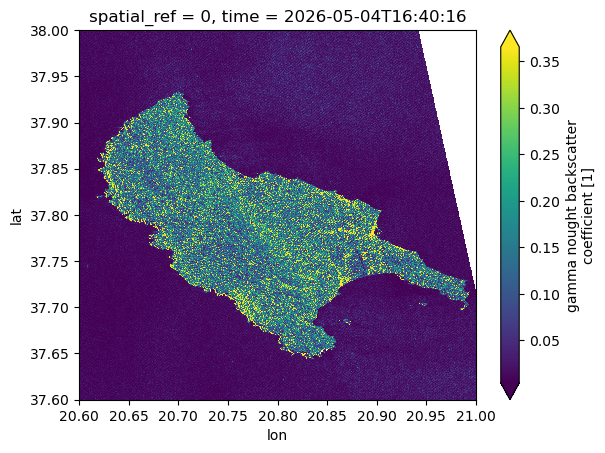

In [8]:
%%time
ds.gamma0_vv.isel(time=0).plot(robust=True)

The same data cube can also be requested in a different coordinate reference system (CRS), such as UTM. The **xcube-eopf** framework supports on-the-fly reprojection to any user-defined CRS.

The resampling behavior can be customized when required. By default, **bilinear interpolation** is applied. Alternatively, **nearest-neighbor interpolation** can be selected, as shown below. See the [xcube-resampling documentation](https://xcube-dev.github.io/xcube-resampling/guide/#common-parameters-for-all-resampling-algorithms) for further details on available resampling and aggregation options.

> **Note:** The requested spatial resolution and bounding box must be specified in the coordinate units of the target CRS.

In [9]:
crs_utm = "EPSG:32631"
bbox_utm = reproject_bbox(bbox, "EPSG:4326", crs_utm)

In [10]:
%%time
ds = store.open_data(
    data_id="sentinel-1-l1-grd",
    bbox=bbox_utm,
    time_range=time_range,
    spatial_res=30,     # in meter
    crs=crs_utm,
)
ds

CPU times: user 52.2 s, sys: 7.31 s, total: 59.5 s
Wall time: 1min 16s


<xarray.Dataset> Size: 62MB
Dimensions:      (time: 3, y: 1730, x: 1482)
Coordinates:
  * time         (time) datetime64[s] 24B 2026-05-04T16:40:16 ... 2026-05-05T...
  * y            (y) float64 14kB 4.362e+06 4.362e+06 ... 4.31e+06 4.31e+06
  * x            (x) float64 12kB 2.051e+06 2.051e+06 ... 2.095e+06 2.095e+06
    spatial_ref  int64 8B 0
Data variables:
    gamma0_vv    (time, y, x) float32 31MB dask.array<chunksize=(1, 1730, 1482), meta=np.ndarray>
    gamma0_vh    (time, y, x) float32 31MB dask.array<chunksize=(1, 1730, 1482), meta=np.ndarray>
Attributes: (5)

And again, the following cell visualizes a single timestamp of the **gamma nought VV** backscatter band (`gamma0_vv`).

CPU times: user 6.14 s, sys: 1.39 s, total: 7.53 s
Wall time: 5.45 s


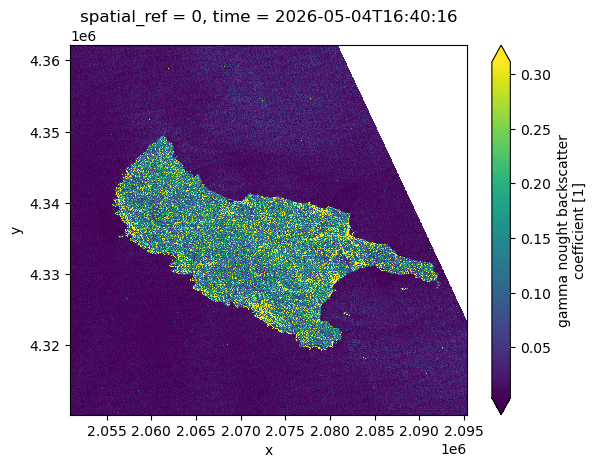

In [11]:
%%time
ds.gamma0_vv.isel(time=0).plot(robust=True)

## Access Sentinel-1 Level-1 SLC ARDC

In this section, we demonstrate the available features and options for opening and generating spatio-temporal data cubes from multiple **Sentinel-1 Level-2 SLC** tiles.

> Note: Support for Sentinel-1 SLC products is currently experimental and under validation.

The opening parameters for this collection are shown below:

In [12]:
store.get_open_data_params_schema(data_id="sentinel-1-l1-slc")

Due to the computationally intensive processing, opening the data cube may take longer. In native mode, each TOPSAR burst is represented as a separate DataTree subgroup, resulting in a complex hierarchical structure that increases the time required to open and inspect the dataset. In analysis mode, additional processing steps such as debursting and burst merging are performed before further processing.

In [13]:
ds = store.open_data(
    data_id="sentinel-1-l1-slc",
    bbox=bbox,
    time_range=time_range,
)
ds

<xarray.Dataset> Size: 50MB
Dimensions:      (time: 3, lat: 1441, lon: 1441)
Coordinates:
  * time         (time) datetime64[s] 24B 2026-05-04T16:40:16 ... 2026-05-05T...
  * lat          (lat) float64 12kB 38.0 38.0 38.0 38.0 ... 37.6 37.6 37.6 37.6
  * lon          (lon) float64 12kB 20.6 20.6 20.6 20.6 ... 21.0 21.0 21.0 21.0
    spatial_ref  int64 8B 0
Data variables:
    gamma0_vh    (time, lat, lon) float32 25MB dask.array<chunksize=(1, 1441, 1441), meta=np.ndarray>
    gamma0_vv    (time, lat, lon) float32 25MB dask.array<chunksize=(1, 1441, 1441), meta=np.ndarray>
Attributes: (5)

And again, the following cell visualizes a single timestamp of the **gamma nought VV** backscatter band (`gamma0_vv`).

CPU times: user 11 s, sys: 2.65 s, total: 13.6 s
Wall time: 17.1 s


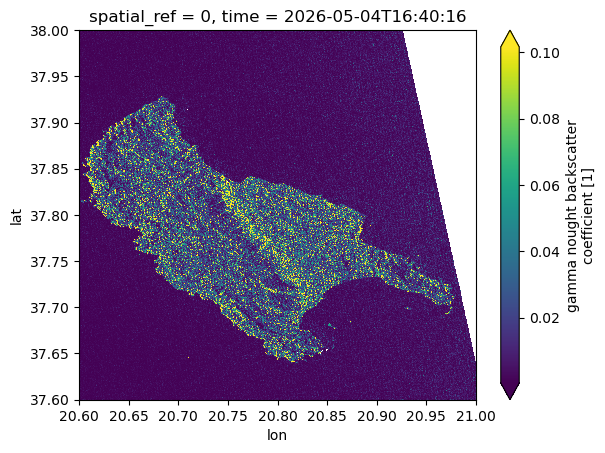

In [14]:
%%time
ds.gamma0_vv.isel(time=0).plot(robust=True)

## Access Sentinel-1 Level-2 OCN ARDC

In this section, we demonstrate how to open and generate spatio-temporal data cubes from multiple **Sentinel-1 Level-2 OCN** observations.

The opening parameters for this collection are shown below:

In [15]:
store.get_open_data_params_schema(data_id="sentinel-1-l2-ocn")

We set `data_id` to `"sentinel-1-l2-ocn"`. As an example, we select the **Balearic Islands** and the surrounding Mediterranean Sea as the region of interest, with observations from the end of May 2025.

In [16]:
%%time
ds = store.open_data(
    data_id="sentinel-1-l2-ocn",
    bbox=[0, 38, 5, 43],
    time_range=["2025-05-27", "2025-05-31"],
)
ds

CPU times: user 7.06 s, sys: 396 ms, total: 7.46 s
Wall time: 22.7 s


<xarray.Dataset> Size: 23MB
Dimensions:                   (time: 7, lat: 557, lon: 424)
Coordinates:
  * time                      (time) datetime64[s] 56B 2025-05-27T05:36:43 .....
  * lat                       (lat) float64 4kB 43.0 42.99 42.98 ... 38.01 38.0
  * lon                       (lon) float64 3kB 0.005907 0.01772 ... 4.991 5.003
    spatial_ref               int64 8B 0
Data variables:
    wind_direction            (time, lat, lon) float32 7MB dask.array<chunksize=(1, 557, 424), meta=np.ndarray>
    wind_speed                (time, lat, lon) float32 7MB dask.array<chunksize=(1, 557, 424), meta=np.ndarray>
    inversion_quality         (time, lat, lon) uint8 2MB dask.array<chunksize=(1, 557, 424), meta=np.ndarray>
    percentage_bright_points  (time, lat, lon) float32 7MB dask.array<chunksize=(1, 557, 424), meta=np.ndarray>
    wind_quality              (time, lat, lon) uint8 2MB dask.array<chunksize=(1, 557, 424), meta=np.ndarray>
Attributes: (7)

The following cell visualizes the **wind speed** and **wind direction** side by side for a selected timestamp.

CPU times: user 3.2 s, sys: 203 ms, total: 3.41 s
Wall time: 2.98 s


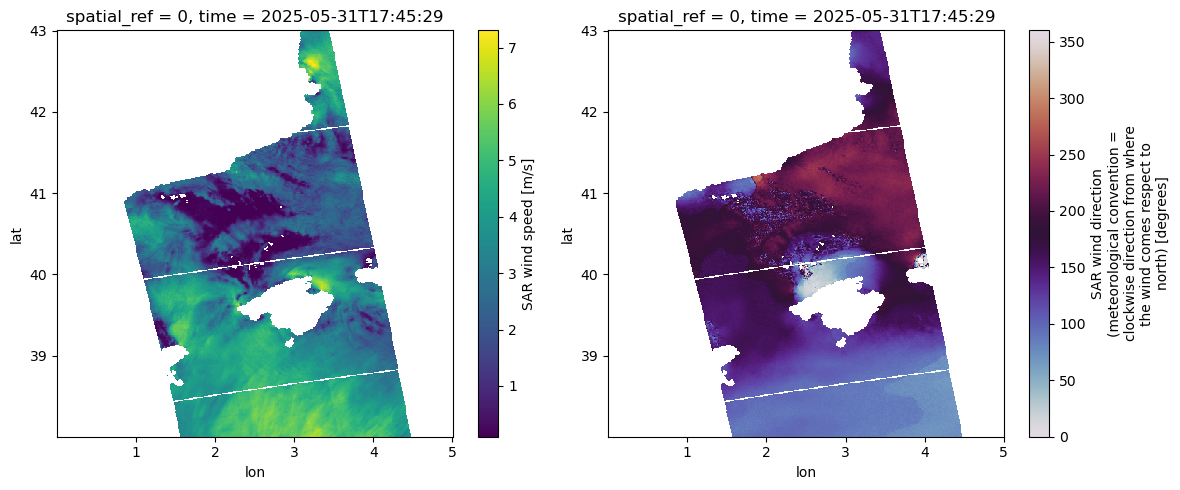

In [17]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ds.wind_speed.isel(time=-1).plot(ax=ax[0], cmap="viridis")
ds.wind_direction.isel(time=-1).plot(ax=ax[1], cmap="twilight", vmin=0, vmax=360)
plt.tight_layout()

---

## Conclusion

This notebook highlighted the main features of the **xcube EOPF Data Store** for Sentinel-1, which enables seamless access to multiple EOPF Zarr products as **analysis-ready data cubes (ARDCs)**.

Key takeaways:

- **3D spatio-temporal data cubes** can be generated from multiple EOPF Sentinel Zarr samples.  
- Supports access to **Sentinel-1 Level-1 GRD** and **Level-2 OCN** collections.
- Data cubes can be requested with any **CRS**, spatial extent, temporal range, and spatial resolution.

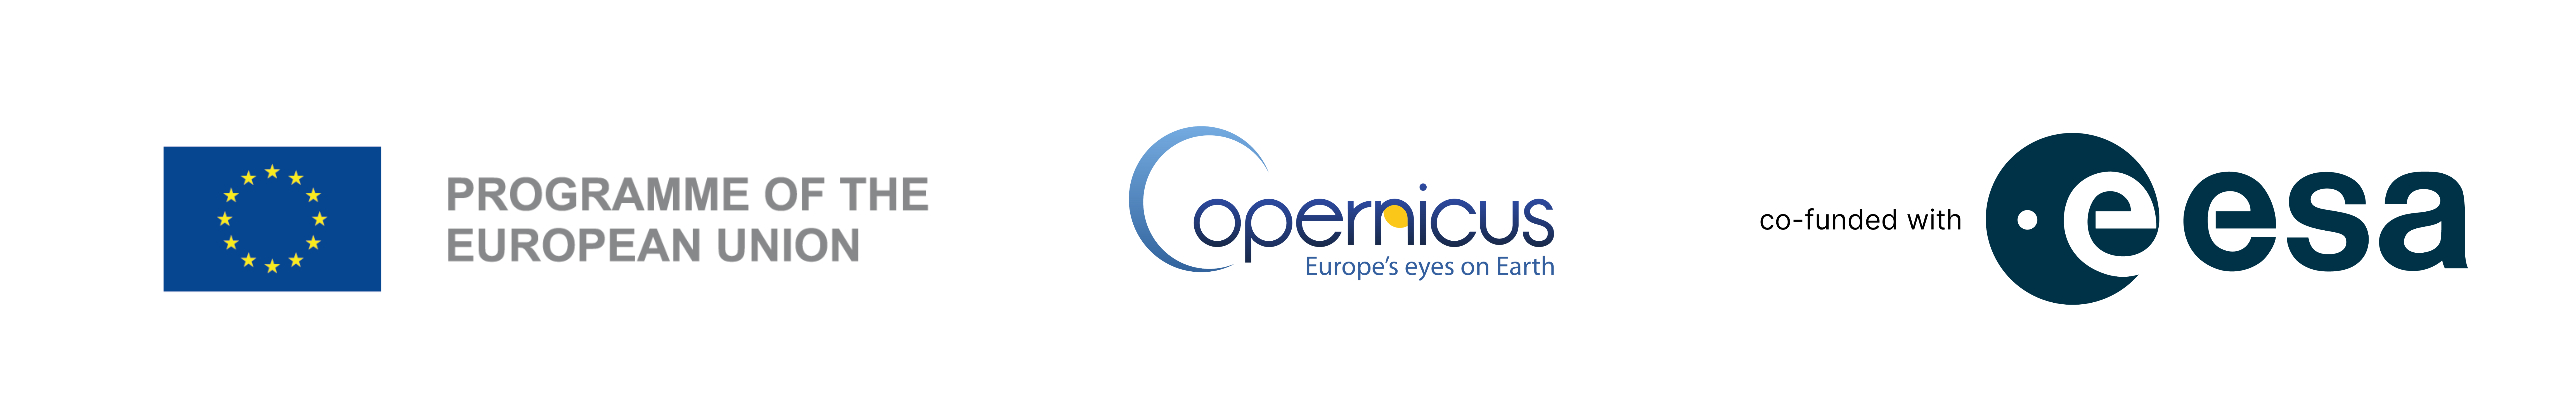